In [5]:
# ==========================================
# CELL 3: MODEL TRAINING & EVALUATION (RANDOM FOREST)
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Bagi data menjadi Data Train (80%) dan Data Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- Pembagian Data Berhasil ---")
print(f"Jumlah Data Latihan (X_train): {X_train.shape[0]} baris")
print(f"Jumlah Data Uji Coba (X_test): {X_test.shape[0]} baris\n")

# 2. Inisialisasi Model Random Forest Regressor
# Kita set n_estimators=100 (artinya model akan membuat 100 pohon keputusan otomatis)
model = RandomForestRegressor(n_estimators=100, random_state=42)

print("Sedang melatih model Random Forest... (Mohon tunggu sebentar)")
# 3. Latih Model menggunakan data Train
model.fit(X_train, y_train)
print("Model BERHASIL dilatih! 🔥\n")

# 4. Uji Coba Model: Prediksi data Test
y_pred = model.predict(X_test)

# 5. Evaluasi Performa Model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- HASIL EVALUASI MODEL ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score (Akurasi Model) : {r2 * 100:.2f}%")

--- Pembagian Data Berhasil ---
Jumlah Data Latihan (X_train): 4000 baris
Jumlah Data Uji Coba (X_test): 1000 baris

Sedang melatih model Random Forest... (Mohon tunggu sebentar)
Model BERHASIL dilatih! 🔥

--- HASIL EVALUASI MODEL ---
Mean Absolute Error (MAE): 8.0753
R² Score (Akurasi Model) : 31.25%


In [4]:
# ==========================================
# CELL 2: PREPROCESSING & FEATURE ENGINEERING
# ==========================================

# 1. Map Day_of_Week dari teks ke angka (0 = Senin, 6 = Minggu)
hari_map = {
    'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3,
    'Friday': 4, 'Saturday': 5, 'Sunday': 6
}
df['Day_of_Week_Num'] = df['Day_of_Week'].map(hari_map)

# 2. Memilih fitur (X) yang berpengaruh ke Engagement Rate (y)
# Kita ambil fitur waktu, metadata konten, dan akun
fitur_numerik = ['Hour_of_Day', 'Day_of_Week_Num', 'Hashtag_Count', 'Content_Length', 'Follower_Count']
fitur_kategori = ['Platform', 'Content_Type', 'Category', 'Sentiment']

# 3. One-Hot Encoding untuk fitur teks/kategori biar jadi angka 0 dan 1
X_kat = pd.get_dummies(df[fitur_kategori], drop_first=True)
X_num = df[fitur_numerik]

# 4. Gabungkan semua fitur menjadi matriks X besar
X = pd.concat([X_num, X_kat], axis=1)

# 5. Tentukan target (y)
y = df['Engagement_Rate']

print("--- Hasil Feature Engineering ---")
print(f"Ukuran Data Fitur (X): {X.shape}")
print(f"Ukuran Data Target (y): {y.shape}")
print("\nNama-nama fitur baru yang siap masuk ke Random Forest:")
print(X.columns.tolist())

--- Hasil Feature Engineering ---
Ukuran Data Fitur (X): (5000, 39)
Ukuran Data Target (y): (5000,)

Nama-nama fitur baru yang siap masuk ke Random Forest:
['Hour_of_Day', 'Day_of_Week_Num', 'Hashtag_Count', 'Content_Length', 'Follower_Count', 'Platform_Instagram', 'Platform_LinkedIn', 'Platform_TikTok', 'Platform_Twitter', 'Platform_YouTube', 'Content_Type_Carousel', 'Content_Type_Community Post', 'Content_Type_Document', 'Content_Type_Duet', 'Content_Type_Live', 'Content_Type_Photo', 'Content_Type_Poll', 'Content_Type_Post', 'Content_Type_Reel', 'Content_Type_Retweet', 'Content_Type_Short', 'Content_Type_Stitch', 'Content_Type_Story', 'Content_Type_Thread', 'Content_Type_Tweet', 'Content_Type_Video', 'Category_Education', 'Category_Entertainment', 'Category_Fashion', 'Category_Fitness', 'Category_Food', 'Category_Gaming', 'Category_Health', 'Category_Lifestyle', 'Category_Sports', 'Category_Technology', 'Category_Travel', 'Sentiment_Neutral', 'Sentiment_Positive']


In [3]:
import pandas as pd

# Load data (pake '../' buat keluar dari folder notebooks dulu baru masuk ke folder data)
df = pd.read_csv('../data/social_media_engagement_dataset.csv')

# Intip nama kolom dan tipe datanya
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Post_ID          5000 non-null   str    
 1   Timestamp        5000 non-null   str    
 2   Platform         5000 non-null   str    
 3   Content_Type     5000 non-null   str    
 4   Category         5000 non-null   str    
 5   Likes            5000 non-null   int64  
 6   Comments         5000 non-null   int64  
 7   Shares           5000 non-null   int64  
 8   Views            5000 non-null   int64  
 9   Saves            5000 non-null   int64  
 10  Follower_Count   5000 non-null   int64  
 11  Engagement_Rate  5000 non-null   float64
 12  Hour_of_Day      5000 non-null   int64  
 13  Day_of_Week      5000 non-null   str    
 14  Hashtag_Count    5000 non-null   int64  
 15  Content_Length   5000 non-null   int64  
 16  Sentiment        5000 non-null   str    
 17  Influencer_Tier  5000 non

In [2]:
import pandas as pd

df = pd.read_csv('../data/social_media_engagement_dataset.csv')

df.head()

,Post_ID,Timestamp,Platform,Content_Type,Category,Likes,Comments,Shares,Views,Saves,Follower_Count,Engagement_Rate,Hour_of_Day,Day_of_Week,Hashtag_Count,Content_Length,Sentiment,Influencer_Tier,Has_Media,Is_Verified
0,POST_04552,2024-01-01 01:42:00,Instagram,Carousel,Business,8287,247,51,29502,20,223080,3.85,1,Monday,16,985,Positive,Macro,True,False
1,POST_02171,2024-01-01 05:05:00,LinkedIn,Document,Health,1711,27,247,24538,139,312647,0.63,5,Monday,9,627,Negative,Macro,False,True
2,POST_00210,2024-01-01 09:18:00,Instagram,Carousel,Food,1527,191,7,5460,359,220737,0.78,9,Monday,27,79,Positive,Macro,True,True
3,POST_01548,2024-01-01 10:58:00,Facebook,Video,Sports,535,178,433,68246,740,428935,0.27,10,Monday,17,554,Neutral,Macro,True,False
4,POST_01350,2024-01-01 13:12:00,Instagram,Photo,Fitness,9706,35,118,25782,611,64384,15.31,13,Monday,5,1136,Positive,Mid-tier,True,False


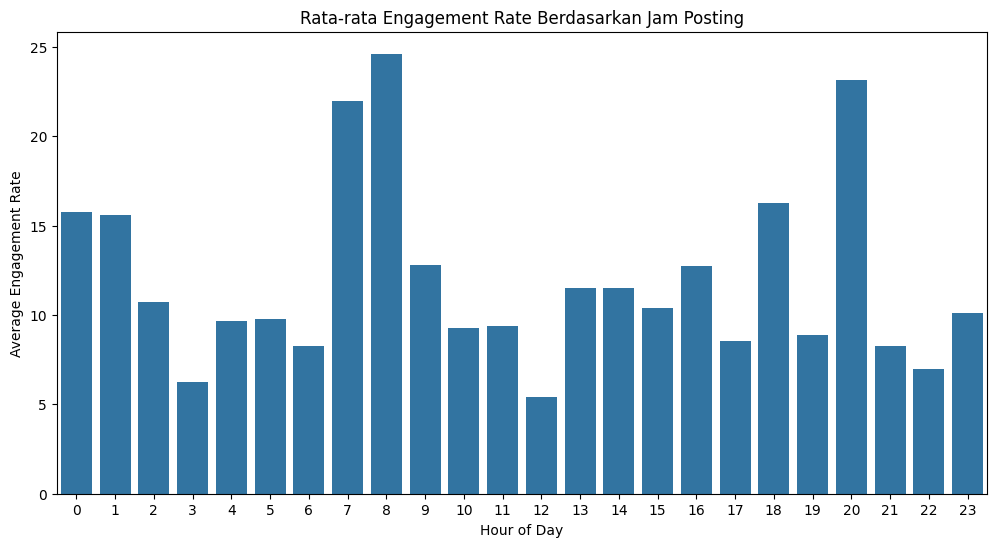

In [28]:
# ==========================================
# Grafik 1: Engagement Rate Berdasarkan Jam Posting
# ==========================================

plt.figure(figsize=(12,6))

hour_engagement = (
    df.groupby('Hour_of_Day')['Engagement_Rate']
    .mean()
    .reset_index()
)

sns.barplot(
    data=hour_engagement,
    x='Hour_of_Day',
    y='Engagement_Rate'
)

plt.title('Rata-rata Engagement Rate Berdasarkan Jam Posting')
plt.xlabel('Hour of Day')
plt.ylabel('Average Engagement Rate')
plt.show()

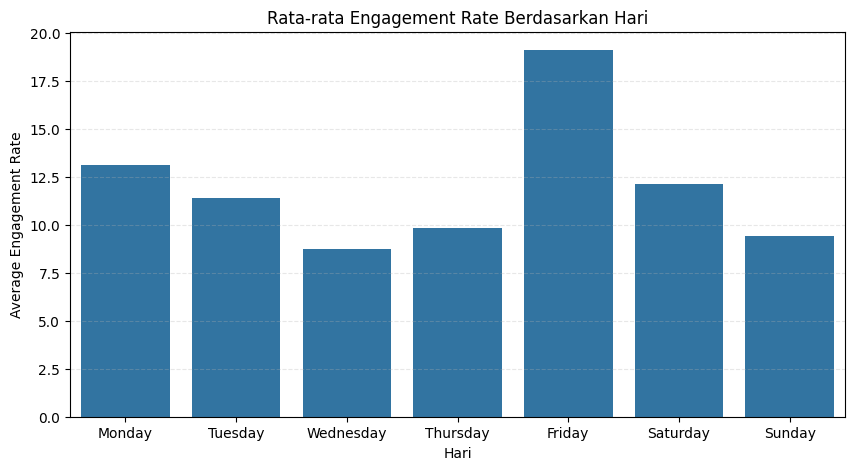

In [25]:
# ==========================================
# Grafik 2: Engagement Rate Berdasarkan Hari
# ==========================================
day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

plt.figure(figsize=(10,5))

day_engagement = (
    df.groupby('Day_of_Week')['Engagement_Rate']
    .mean()
    .reindex(day_order)
    .reset_index()
)

sns.barplot(
    data=day_engagement,
    x='Day_of_Week',
    y='Engagement_Rate'
)

plt.title('Rata-rata Engagement Rate Berdasarkan Hari')
plt.xlabel('Hari')
plt.ylabel('Average Engagement Rate')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

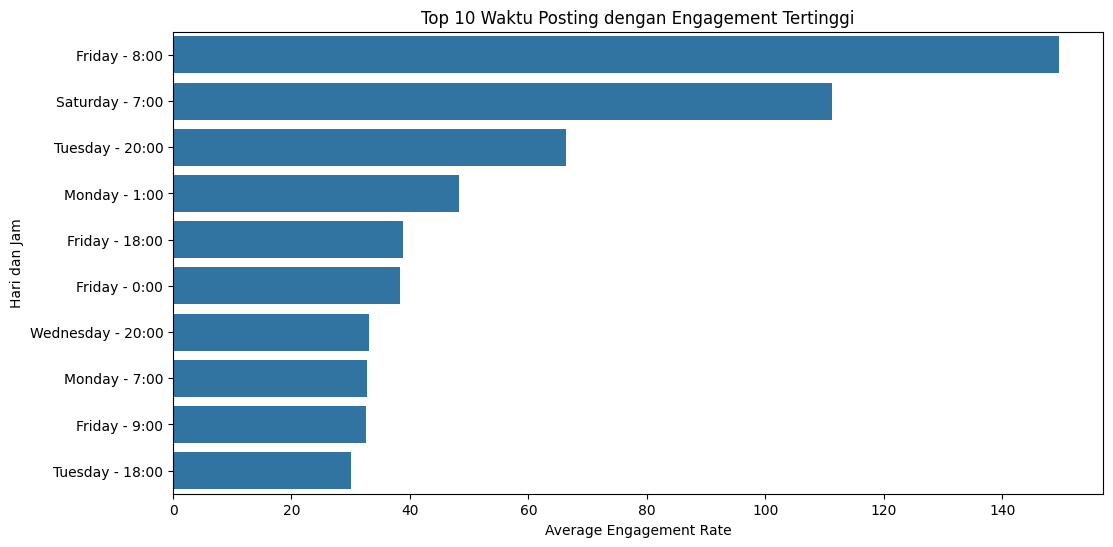

In [29]:
# ==========================================
# Grafik 3: Top 10 Kombinasi Hari dan Jam
# ==========================================
top_time = (
    df.groupby(['Day_of_Week','Hour_of_Day'])['Engagement_Rate']
    .mean()
    .reset_index()
    .sort_values('Engagement_Rate', ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_time,
    x='Engagement_Rate',
    y=top_time['Day_of_Week'].astype(str) +
      ' - ' +
      top_time['Hour_of_Day'].astype(str) + ':00'
)

plt.title('Top 10 Waktu Posting dengan Engagement Tertinggi')
plt.xlabel('Average Engagement Rate')
plt.ylabel('Hari dan Jam')

plt.show()

Kesimpulan EDA Fitur Waktu

1. Engagement rate dipengaruhi oleh waktu posting.
2. Jam terbaik untuk posting adalah 08.00 
3. Hari terbaik untuk posting adalah jum'at
4. Kombinasi hari dan jam terbaik adalah hari Jum'at pukul 08.00 Oleh karena itu, waktu posting perlu diperhatikan untuk meningkatkan engagement.